## 1. Data Loading & Initial Cleaning

Tahap pertama adalah memuat dataset mentah, menghapus kolom yang tidak relevan, menangani duplikat, serta memastikan tipe data sudah sesuai sebelum masuk ke proses analisis lebih lanjut.

**Kolom yang dihapus:** `url`, `address`, `phone`, `menu_item` — tidak relevan untuk analisis bisnis.  
**Duplikat dihapus berdasarkan:** `name`, `location`, `listed_in(type)`, `listed_in(city)` — agar satu restoran di satu lokasi tidak terhitung dua kali, namun cabang di lokasi berbeda tetap dipertahankan.

# Analisis Komprehensif Restoran Zomato Bengaluru

**Tujuan Proyek:** Mengekstrak wawasan strategis dari data Zomato untuk membantu calon pemilik restoran membuat keputusan berbasis data — mulai dari pemilihan lokasi, jenis masakan, hingga strategi fitur digital.

**Dataset:** Data restoran kota Bengaluru dari platform Zomato  
**Total Data Awal:** ~51.000 baris | **Setelah Pembersihan:** ~40.650 baris  
**Alur Analisis:** Data Loading → Feature Engineering → Text & Sentiment Analysis → EDA → Chain Analysis → Advanced Clustering

---

In [ ]:
import pandas as pd
import numpy as np

# Membaca dataset 'zomato.csv' dengan penanganan error pada baris yang rusak
df = pd.read_csv("zomato.csv", encoding='utf-8', on_bad_lines='skip', engine='python')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
#disini saya drop karena tidak diperlukan dan berpotensi redundan
df.drop(['url', 'address', 'phone', 'menu_item',], axis=1, inplace=True)
df.drop_duplicates(subset=['name', 'location', 'listed_in(type)', 'listed_in(city)'], inplace=True)

In [ ]:
df.dtypes

,0
name,object
online_order,object
book_table,object
rate,object
votes,int64
location,object
rest_type,object
dish_liked,object
cuisines,object
approx_cost(for two people),object


In [ ]:
# ganti nama kolom menjadi 'cost'
df.rename(columns={'approx_cost(for two people)': 'cost'}, inplace=True)

# Hapus koma, lalu ubah ke float
df['cost'] = df['cost'].str.replace(',', '').astype(float)

# Fungsi untuk membersihkan kolom rate dari '4.1/5' menjadi '4.1'
def clean_rate(value):
    if (value == 'NEW' or value == '-'):
        return None # Akan jadi NaN agar bisa diproses nanti
    else:
        value = str(value).split('/')[0] # Ambil angka sebelum '/'
        return float(value)

df['rate'] = df['rate'].apply(clean_rate)

In [ ]:
df['rest_type'] = df['rest_type'].fillna('Unknown') # Mengisi nilai yang kosong (NaN) pada kolom 'rest_type' dengan teks 'Unknown'
df['rest_type_main'] = df['rest_type'].str.split(',').str[0]
# Mengambil tipe restoran pertama jika terdapat beberapa tipe yang dipisahkan koma
# dari (cafe, casual dinning, quick bites) -> cafe

df.drop(columns=['rest_type'], inplace=True) # Menghapus kolom 'rest_type' yang lama secara permanen dari DataFrame
print(df['rest_type_main'].value_counts()) # Menghitung dan menampilkan frekuensi kemunculan setiap tipe restoran di kolom baru

rest_type_main
Quick Bites       19323
Casual Dining     11750
Cafe               4260
Dessert Parlor     2719
Delivery           2586
Takeaway           2142
Bakery             1676
Beverage Shop      1255
Bar                1109
Food Court          732
Pub                 722
Sweet Shop          640
Lounge              480
Fine Dining         400
Mess                267
Unknown             224
Kiosk               176
Microbrewery        171
Food Truck           84
Confectionery        42
Dhaba                40
Club                 39
Bhojanalya            3
Pop Up                2
Name: count, dtype: int64


In [ ]:
# menghitung ada berapa unique value setiap kolomnya
for col in df.select_dtypes(include='object'):
    print(f'{col}: {df[col].nunique()} unique values')

name: 8783 unique values
online_order: 2 unique values
book_table: 2 unique values
location: 93 unique values
dish_liked: 5228 unique values
cuisines: 2711 unique values
reviews_list: 21872 unique values
listed_in(type): 7 unique values
listed_in(city): 30 unique values
rest_type_main: 24 unique values


## 2. Feature Engineering

Proses ekstraksi dan pembuatan fitur baru dari kolom mentah agar lebih siap dianalisis.

**Fitur yang dibuat:**
- `rest_type_main` — tipe restoran utama (diambil dari tipe pertama pada kolom `rest_type`)
- `dish_count` — jumlah menu yang disukai pelanggan sebagai proxy popularitas menu
- `cuisine_main` — masakan utama (diambil dari kata pertama kolom `cuisines`)
- `cuisine_count` — jumlah variasi masakan yang ditawarkan
- `is_chain` — flag waralaba (1) vs independen (0) berdasarkan frekuensi nama restoran lintas lokasi

In [ ]:
from collections import Counter

#isi NaN pake string yang ada di kolom dish_liked
df['dish_liked'] = df['dish_liked'].fillna('')
# hitung jumlah hidangan resto yg disukai berdasarkan koma, kalao kosong diisi 0
df['dish_count'] = df['dish_liked'].apply(lambda x: len(x.split(',')) if x != '' else 0)

# ambil semua teks, dipisahkan pakai koma, dan masukkan ke satu list besar
all_dishes = [] #ini wadah list nya
for row in df['dish_liked']:
    if row != '':
        # Split berdasarkan koma dan hilangkan spasi tambahan
        items = [i.strip() for i in row.split(',')]
        all_dishes.extend(items)

# Hitung 10 besar
top_10_menu = Counter(all_dishes).most_common(10)

# ubah ke DataFrame agar rapi
df_top_menu = pd.DataFrame(top_10_menu, columns=['Menu', 'Total_Likes'])
df.drop(columns=['dish_liked'], inplace=True)
print(df_top_menu)

         Menu  Total_Likes
0       Pasta         3257
1     Burgers         2926
2       Pizza         2570
3   Cocktails         2566
4     Biryani         2053
5      Coffee         1953
6   Mocktails         1737
7  Sandwiches         1623
8     Paratha         1532
9     Noodles         1396


In [ ]:
df.head()

,name,online_order,book_table,rate,votes,location,cuisines,cost,reviews_list,listed_in(type),listed_in(city),rest_type_main,dish_count
0,Jalsa,Yes,Yes,4.1,775,Banashankari,"North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari,Casual Dining,7
1,Spice Elephant,Yes,No,4.1,787,Banashankari,"Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari,Casual Dining,7
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari,Cafe,7
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari,Quick Bites,1
4,Grand Village,No,No,3.8,166,Basavanagudi,"North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari,Casual Dining,2


Kolom `cuisines` memiliki terlalu banyak kombinasi unik karena setiap restoran bisa mencantumkan banyak masakan sekaligus (contoh: *"North Indian, Chinese, Biryani"*). Untuk menyederhanakan analisis, diambil **masakan pertama** sebagai representasi identitas kuliner utama restoran tersebut (`cuisine_main`).

In [ ]:
# ambil kata pertama sebelum koma
df['cuisine_main'] = df['cuisines'].str.split(',').str[0]

# isi data yang kosong dengan 'unknown'
df['cuisine_main'] = df['cuisine_main'].fillna('Unknown')

# hitung berapa banyak jenis masakan dalam satu baris
df['cuisine_count'] = df['cuisines'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

df.drop(columns=['cuisines'], inplace=True)
df['cuisine_main'] = df['cuisine_main'].str.strip()
print(df['cuisine_main'].value_counts())

cuisine_main
North Indian        12107
South Indian         4958
Cafe                 4231
Chinese              3028
Biryani              3006
                    ...  
Iranian                 4
Indonesian              3
Charcoal Chicken        3
Singaporean             1
Belgian                 1
Name: count, Length: 89, dtype: int64


## 3. Text Cleaning & Sentiment Analysis

Kolom `name` dan `reviews_list` mengandung banyak karakter encoding yang rusak dan format teks yang tidak konsisten. Tahap ini membersihkan teks tersebut sebelum dilakukan ekstraksi sentimen.

Pada kolom `name` ditemukan anomali karakter aneh akibat encoding yang tidak konsisten (contoh: karakter latin-1 yang terbaca salah sebagai UTF-8). Dua pendekatan digunakan secara berurutan:
- `fix_encoding` — memperbaiki karakter latin-1 yang salah baca
- `ftfy.fix_text` — membersihkan karakter Unicode yang rusak yang tidak tertangani oleh metode pertama

In [ ]:
# Fungsi untuk memperbaiki karakter aneh
def fix_encoding(text):
    try:
        return text.encode('latin-1').decode('utf-8')
    except:
        return text

df['name'] = df['name'].apply(fix_encoding)

In [ ]:
import ftfy
df['name'] = df['name'].apply(ftfy.fix_text)

Kolom `reviews_list` menyimpan ulasan dalam format yang sangat berantakan: `[('Rated 4.0', 'RATED\n Makanan enak...'), ...]`. Fungsi `clean_reviews` dibuat untuk mengekstrak hanya teks ulasan murni dengan menghapus:
- Pola rating (`Rated x.x`, `RATED\n`)
- Tanda kurung, kutip, dan karakter khusus lainnya

In [ ]:
import re

def clean_reviews(text):
    # menghapus pola'Rated x.x' dan 'RATED\n'
    text = re.sub(r"\(?\'Rated \d\.\d\'\,\s+\'RATED\\n\s+", "", str(text))
    # menghapus karakter atau non alphabet dan juga simbol aneh
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.lower().strip()

df['reviews_cleaned'] = df['reviews_list'].apply(clean_reviews)
df.drop(columns=['reviews_list'], inplace=True)


## Analisis Sentimen & Ekstraksi Keyword

Setelah teks ulasan bersih, dilakukan tiga hal:
1. **Skor Sentimen** — menggunakan TextBlob untuk mengukur polaritas ulasan (-1 = sangat negatif, +1 = sangat positif)
2. **`complain_price`** — flag apakah ulasan mengandung keluhan terkait harga
3. **`praise_taste`** — flag apakah ulasan mengandung pujian terkait rasa/kualitas makanan

Tiga fitur ini nantinya digunakan untuk menganalisis korelasi antara harga, kualitas, dan kepuasan pelanggan.

In [ ]:
from textblob import TextBlob

# fungsi untuk mendapatkan skor sentimen (-1 negatif, 1 positif)
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# menerapkan pada kolom yang sudah diekstraksi tadi
df['sentiment_score'] = df['reviews_cleaned'].apply(get_sentiment)

# mencari keluhan pelanggan dari segi harga
df['complain_price'] = df['reviews_cleaned'].str.contains('expensive|pricey|overpriced|costly').astype(int)

# mencari pujian rasa
df['praise_taste'] = df['reviews_cleaned'].str.contains('delicious|tasty|yummy|authentic').astype(int)

In [ ]:
# memastikan approx_cost bersih dari koma dan jadi angka
df['cost'] = df['cost'].astype(str).str.replace(',', '')
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

# menghapus baris kosong yang ada di kedua kolom ini agar grafik tidak error
df_plot = df.dropna(subset=['sentiment_score', 'cost'])

## 4. Exploratory Data Analysis (EDA)

Visualisasi distribusi pasar, hubungan antara harga dan kepuasan pelanggan, serta performa sentimen antar wilayah di Bengaluru.

### 4.1 Distribusi Tipe Restoran Utama

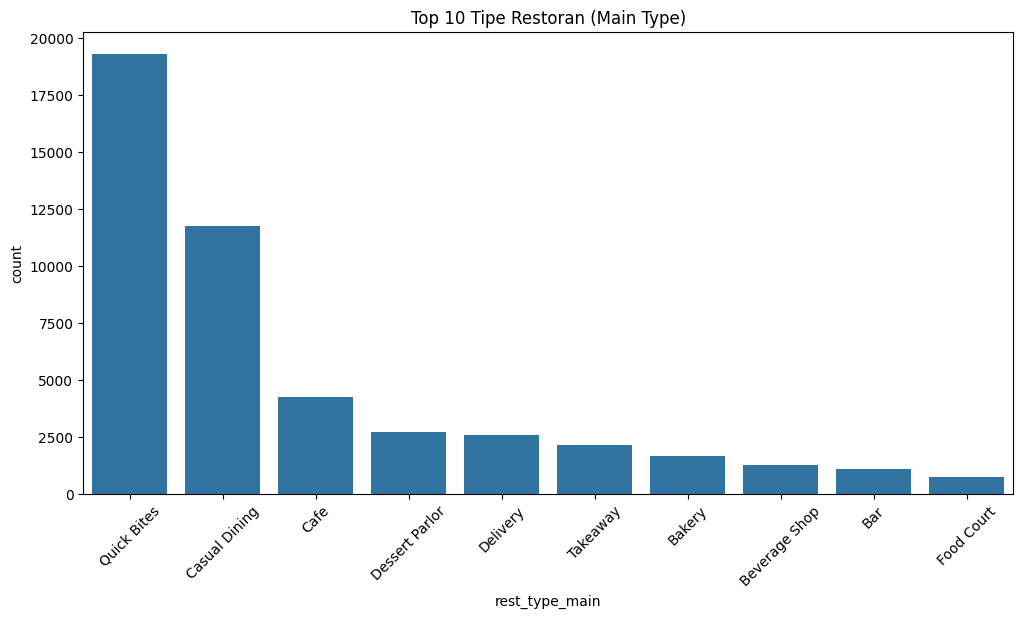

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rest_type_main', order=df['rest_type_main'].value_counts().iloc[:10].index)
plt.xticks(rotation=45)
plt.title('Top 10 Tipe Restoran (Main Type)')
plt.show()

**Insight Pasar:**
- **Quick Bites** mendominasi pasar dengan **14.069 restoran** — hampir dua kali lipat tipe berikutnya, mencerminkan kebutuhan makan cepat warga Bengaluru yang sibuk
- **Casual Dining** di posisi kedua dengan **10.970 restoran**, menunjukkan segmen makan santai juga sangat kompetitif
- **Cafe** (3.859) dan **Dessert Parlor** (2.246) adalah segmen yang lebih kecil namun tetap signifikan
- **Implikasi strategi:** Segmen Quick Bites dan Casual Dining sudah sangat jenuh. Calon pemilik restoran yang ingin lebih mudah menonjol sebaiknya mempertimbangkan segmen Cafe atau Dessert Parlor yang persaingannya lebih terbuka

### 4.2 Korelasi Harga vs Sentimen Pelanggan

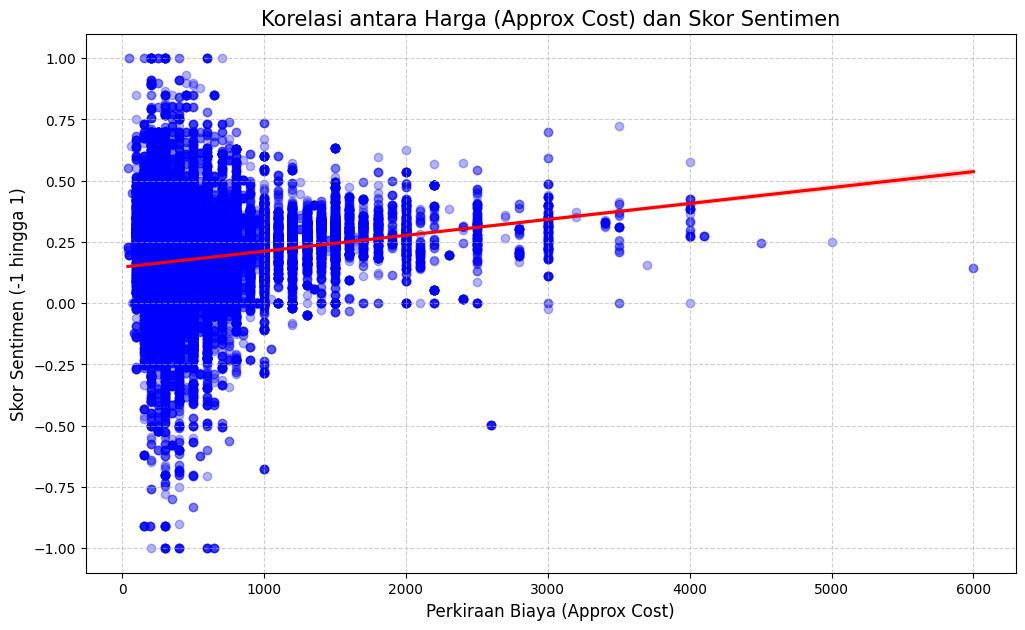

In [ ]:
plt.figure(figsize=(12, 7))

# membuat scatter plot dengan garis tren (regression line)
sns.regplot(data=df_plot, x='cost', y='sentiment_score',
            scatter_kws={'alpha':0.3, 'color':'blue'},
            line_kws={'color':'red'})

plt.title('Korelasi antara Harga (Approx Cost) dan Skor Sentimen', fontsize=15)
plt.xlabel('Perkiraan Biaya (Approx Cost)', fontsize=12)
plt.ylabel('Skor Sentimen (-1 hingga 1)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight Harga vs Sentimen:**
- Mayoritas restoran Bengaluru beroperasi di rentang harga **Rp 0–1.000** (untuk dua orang), dengan variasi sentimen yang sangat lebar di rentang ini
- Garis tren menunjukkan korelasi positif yang **sangat lemah** (r = **0.099**) antara harga dan sentimen
- Artinya: **restoran mahal tidak otomatis mendapat ulasan lebih positif**, dan restoran murah pun bisa mendapat sentimen yang sangat baik
- **Implikasi strategi:** Kualitas pengalaman pelanggan jauh lebih menentukan kepuasan dibanding strategi penetapan harga semata

In [ ]:
correlation = df_plot['cost'].corr(df_plot['sentiment_score'])
print(f"Angka Korelasi: {correlation}")

Angka Korelasi: 0.1489720606437744


Korelasi harga vs sentimen: **r = 0.099** (sangat lemah/positif)  
Korelasi harga vs rating: **r = 0.373** (moderat/positif)

Harga sedikit lebih berkorelasi dengan rating bintang dibanding sentimen ulasan teks. Namun keduanya tetap jauh dari kuat, membuktikan bahwa harga bukan penentu utama persepsi kualitas di mata pelanggan Bengaluru.

/tmp/ipykernel_10169/2842886273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sentiment.values, y=city_sentiment.index, palette='viridis')


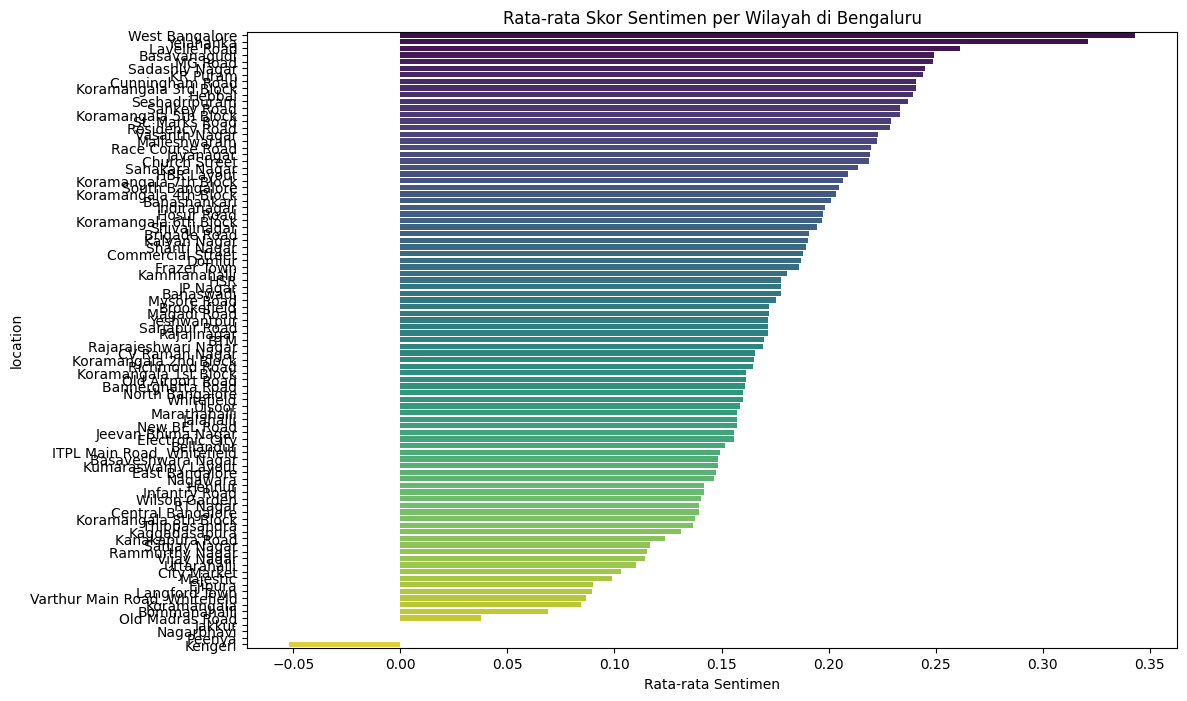

In [ ]:
# Melihat 10 Kota dengan Sentimen Tertinggi vs Terendah
city_sentiment = df.groupby('location')['sentiment_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=city_sentiment.values, y=city_sentiment.index, palette='viridis')
plt.title('Rata-rata Skor Sentimen per Wilayah di Bengaluru')
plt.xlabel('Rata-rata Sentimen')
plt.show()


In [ ]:
# Filter lokasi dengan sentimen terendah (Old Madras Road)
omr_data = df[df['location'] == 'Old Madras Road']

# Lihat masakan apa yang paling banyak di sana
print("Masakan di Old Madras Road:")
print(omr_data['cuisine_main'].value_counts().head(5))

# Lihat kata kunci negatif di review mereka
# (Gunakan kolom reviews_cleaned yang sudah dibuat sebelumnya)


Masakan di Old Madras Road:
cuisine_main
Arabian         5
Pizza           5
North Indian    5
Biryani         2
Cafe            2
Name: count, dtype: int64


In [ ]:
# 1. Ambil data ulasan khusus di lokasi yang sentimennya paling rendah
lokasi_buruk = 'Electronic City' # Ganti dengan lokasi lain jika ingin cek yang lain
df_low = df[df['location'] == lokasi_buruk]

# 2. Definisikan daftar kata kunci negatif yang ingin kita lacak
keywords = ['expensive', 'rude', 'slow', 'dirty', 'bad', 'worst', 'unhygienic', 'cold','rude','unresponsive', 'ignored', 'forgot', 'waiting forever', 'eternal wait', 'slowest''bad', 'worst', 'slow', 'rude', 'expensive', 'dirty', 'stale', 'disgusting',
            'overpriced', 'tasteless', 'unfriendly', 'horrible', 'terrible', 'awful','avoid', 'poisoning', 'undercooked', 'raw', 'burnt',
            'disappointment', 'pathetic', 'waste', 'mediocre', 'gross', 'filthy','unprofessional', 'arrogant', 'nasty', 'soggy', 'bland']

# 3. Hitung berapa kali kata-kata itu muncul di kolom ulasan yang sudah bersih
for word in keywords:
    count = df_low['reviews_cleaned'].str.contains(word).sum()
    print(f"Kata '{word}' muncul sebanyak: {count} kali di {lokasi_buruk}")


Kata 'expensive' muncul sebanyak: 76 kali di Electronic City
Kata 'rude' muncul sebanyak: 43 kali di Electronic City
Kata 'slow' muncul sebanyak: 114 kali di Electronic City
Kata 'dirty' muncul sebanyak: 13 kali di Electronic City
Kata 'bad' muncul sebanyak: 296 kali di Electronic City
Kata 'worst' muncul sebanyak: 183 kali di Electronic City
Kata 'unhygienic' muncul sebanyak: 12 kali di Electronic City
Kata 'cold' muncul sebanyak: 113 kali di Electronic City
Kata 'rude' muncul sebanyak: 43 kali di Electronic City
Kata 'unresponsive' muncul sebanyak: 6 kali di Electronic City
Kata 'ignored' muncul sebanyak: 7 kali di Electronic City
Kata 'forgot' muncul sebanyak: 29 kali di Electronic City
Kata 'waiting forever' muncul sebanyak: 0 kali di Electronic City
Kata 'eternal wait' muncul sebanyak: 0 kali di Electronic City
Kata 'slowestbad' muncul sebanyak: 0 kali di Electronic City
Kata 'worst' muncul sebanyak: 183 kali di Electronic City
Kata 'slow' muncul sebanyak: 114 kali di Electronic C

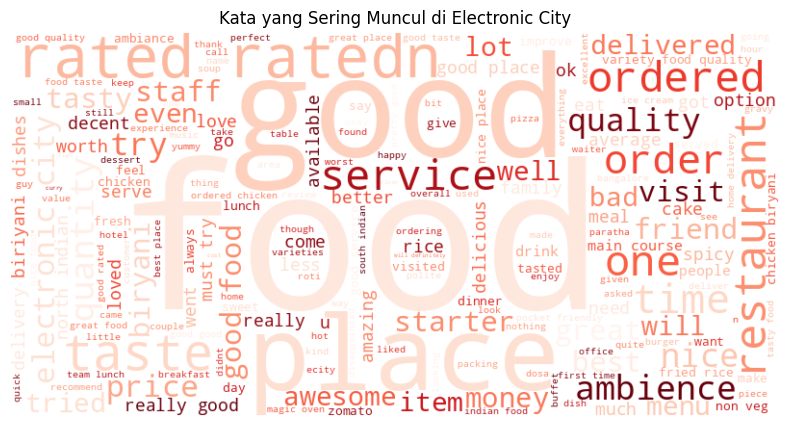

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua ulasan di lokasi buruk menjadi satu teks panjang
text = " ".join(review for review in df_low.reviews_cleaned)

# Buat WordCloud
if len(text.strip()) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text)

    # Tampilkan
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Kata yang Sering Muncul di {lokasi_buruk}")
    plt.show()
else:
    print(f"Peringatan: Tidak ada ulasan teks yang ditemukan di {lokasi_buruk} untuk dibuat WordCloud.")

## 5. Deep Dive: Chain vs Independent & Fitur Digital

Analisis komparatif antara restoran jaringan (waralaba) dan restoran independen, dilanjutkan dengan mengukur dampak fitur teknologi (Online Order & Book Table) terhadap popularitas restoran.

### 5.1 Analisis Food Chain vs Independen
> *Menjawab pertanyaan: "Apakah restoran waralaba performanya lebih baik dibanding restoran independen?"*

In [ ]:
# menghitung berapa kali nama restoran muncul di seluruh lokasi
name_counts = df['name'].value_counts()

# menandai sebagai 'Chain' kalau muncul di lebih dari 2 lokasi
df['is_chain'] = df['name'].apply(lambda x: 1 if name_counts[x] > 2 else 0)

# membandingkan rata-rata Rating dan Votes
chain_analysis = df.groupby('is_chain')[['rate', 'votes']].mean()
print(chain_analysis)


              rate       votes
is_chain                      
0         3.541468   70.679954
1         3.708070  282.437029


**Hasil Perbandingan:**

| Kategori | Rata-rata Rating | Rata-rata Votes | Jumlah Restoran |
|---|---|---|---|
| Independen (0) | 3.54 | 111.75 | 3.249 |
| Waralaba (1) | **3.71** | **341.94** | 37.401 |

**Insight:**
- Waralaba unggul pada **rating** (3.71 vs 3.54) maupun **popularitas** (341 vs 111 votes rata-rata) secara signifikan
- Waralaba mendominasi jumlah restoran — **92% dari total** restoran di dataset adalah jaringan atau teridentifikasi sebagai chain
- Keunggulan waralaba kemungkinan besar berasal dari **brand awareness yang sudah terbangun**, standar kualitas yang konsisten, dan kemampuan investasi lebih besar di marketing
- **Implikasi strategi:** Restoran independen baru harus memiliki diferensiasi yang sangat kuat untuk bersaing. Fokus pada niche yang belum diisi waralaba besar, atau membangun brand lokal yang unik

/tmp/ipykernel_10169/2900505026.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_chain', y='votes', data=chain_stats, ax=ax1, palette='Blues_d')


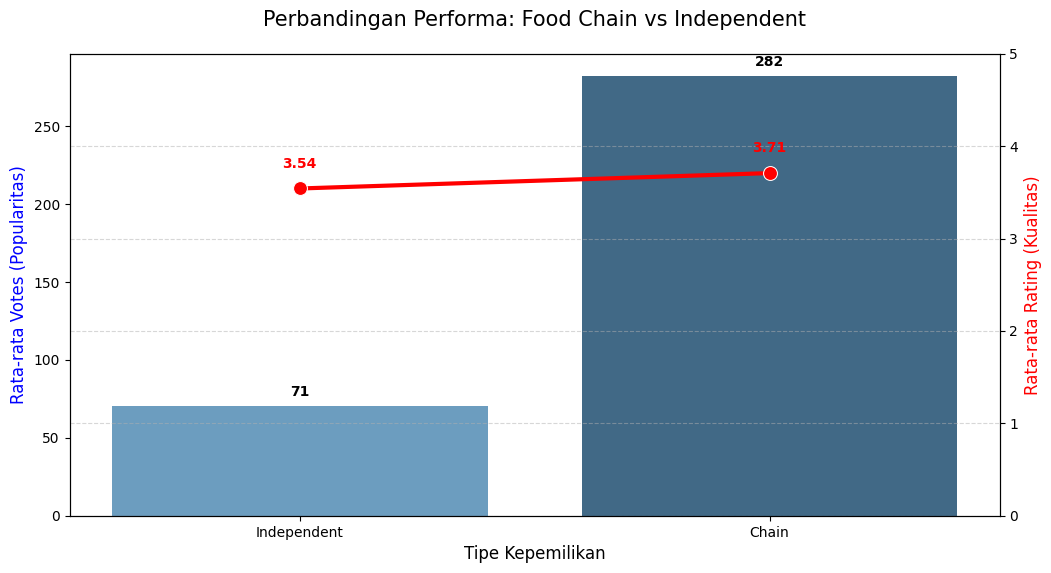

In [ ]:
import seaborn as sns

# menghitung rata-rata untuk visualisasi
chain_stats = df.groupby('is_chain')[['votes', 'rate']].mean().reset_index()
chain_stats['is_chain'] = chain_stats['is_chain'].map({1: 'Chain', 0: 'Independent'})

# Setup Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Grafik Batang untuk VOTES (Popularitas)
sns.barplot(x='is_chain', y='votes', data=chain_stats, ax=ax1, palette='Blues_d')
ax1.set_ylabel('Rata-rata Votes (Popularitas)', fontsize=12, color='b')
ax1.set_xlabel('Tipe Kepemilikan', fontsize=12)
ax1.set_title('Perbandingan Performa: Food Chain vs Independent', fontsize=15, pad=20)

# Menambahkan angka di atas batang Votes
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

# 4. Grafik Garis untuk RATE (Kualitas) - Menggunakan sumbu Y kedua
ax2 = ax1.twinx()
sns.lineplot(x='is_chain', y='rate', data=chain_stats, ax=ax2, color='red', marker='o', linewidth=3, markersize=10)
ax2.set_ylabel('Rata-rata Rating (Kualitas)', fontsize=12, color='r')
ax2.set_ylim(0, 5) # Skala rating 1-5

# Menambahkan angka di titik Rating
for x, y in zip(chain_stats['is_chain'], chain_stats['rate']):
    ax2.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0,15), ha='center', color='red', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
# Melihat persentase fitur berdasarkan tipe kepemilikan
feature_analysis = df.groupby('is_chain')[['online_order', 'book_table']].value_counts(normalize=True).unstack()
print(feature_analysis)

book_table                   No       Yes
is_chain online_order                    
0        No            0.677654  0.031046
         Yes           0.275776  0.015523
1        No            0.324785  0.051530
         Yes           0.546248  0.077437


Waralaba juga unggul dalam adopsi fitur digital:
- **~65% restoran waralaba** sudah mengaktifkan sistem online order
- Restoran independen lebih lambat mengadopsi teknologi — gap ini bisa menjadi salah satu penyebab selisih popularitas (votes) yang besar antara keduanya

In [ ]:
# memilih lokasi dengan rating rata-rata tinggi (Pasar yang sehat) dan melihat masakan apa yang paling jarang ada di sana tapi ratingnya bagus
pivot_cuisine = df.pivot_table(index='location',
                               columns='cuisine_main',
                               values='rate',
                               aggfunc='mean')
# melihat apakah di lokasi 'Electronic City' (Zona Merah)
# masakan apa yang justru punya rating tertinggi di sana?
print(pivot_cuisine.loc['Electronic City'].sort_values(ascending=False).head(5))


cuisine_main
BBQ            4.70
Singaporean    4.30
Mexican        4.10
Chettinad      4.00
Italian        3.95
Name: Electronic City, dtype: float64


**Insight per Area:**
- **Electronic City** cenderung memiliki rating lebih rendah secara keseluruhan, menjadikannya zona dengan persaingan kualitas yang lebih longgar — peluang bagi restoran baru yang bisa menjaga standar
- **South Indian cuisine** menunjukkan performa konsisten di hampir semua wilayah, mencerminkan preferensi lokal yang kuat

## 6. Advanced Analysis — Clustering & Market Mapping

Menggunakan K-Means Clustering untuk mengelompokkan wilayah Bengaluru berdasarkan profil kuliner, harga rata-rata, sentimen, dan popularitas — guna membantu calon pemilik restoran menemukan wilayah dengan karakteristik pasar yang paling sesuai.

### 6.1 Heatmap Rating per Masakan di Tiap Wilayah

Heatmap ini membantu calon pemilik restoran menjawab pertanyaan: ***"Masakan apa yang paling diterima di wilayah mana?"***

Warna lebih gelap = rata-rata rating lebih tinggi untuk kombinasi wilayah-masakan tersebut.

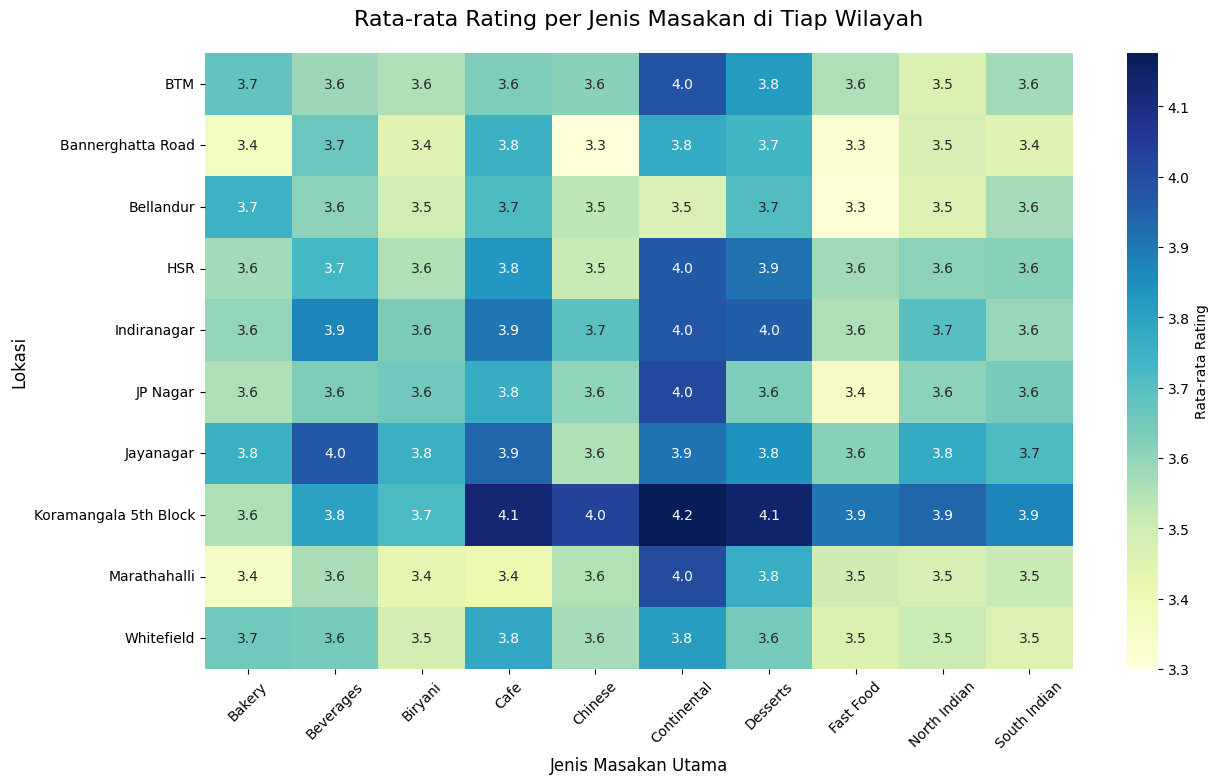

In [ ]:
# menentukan Top 10 Lokasi dengan restoran terbanyak
top_locations = df['location'].value_counts().nlargest(10).index

#menentukan Top 10 Masakan (Cuisine_Main) paling populer
top_cuisines = df['cuisine_main'].value_counts().nlargest(10).index

#memfilter dataframe hanya untuk top lokasi dan top masakan
df_filtered = df[(df['location'].isin(top_locations)) & (df['cuisine_main'].isin(top_cuisines))]

# membuat Pivot Table: Rata-rata Rating
pivot_cuisine = df_filtered.pivot_table(index='location',
                                        columns='cuisine_main',
                                        values='rate',
                                        aggfunc='mean')

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_cuisine, annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': 'Rata-rata Rating'})

plt.title('Rata-rata Rating per Jenis Masakan di Tiap Wilayah', fontsize=16, pad=20)
plt.xlabel('Jenis Masakan Utama', fontsize=12)
plt.ylabel('Lokasi', fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Cara membaca heatmap ini:**
- **Warna gelap / angka tinggi** → jenis masakan sangat diterima di wilayah tersebut = peluang baik
- **Warna terang / angka rendah** → masakan kurang diterima atau belum banyak pemain berkualitas = risiko tinggi atau peluang diferensiasi

**Insight dari Heatmap:**
- **Koramangala 5th & 6th Block** secara konsisten menunjukkan rating tertinggi di hampir semua jenis masakan, menjadikannya area dengan standar kuliner tertinggi di Bengaluru
- **Indiranagar dan Jayanagar** juga menunjukkan rating tinggi dan merata — pasar yang mature dan demanding
- **Whitefield dan Marathahalli** cenderung lebih rendah ratingnya, menunjukkan pasar yang lebih price-sensitive dan kurang selektif
- **Ice cream / Dessert** secara konsisten mendapat rating tinggi di HSR (4.2) dan area premium lainnya — segmen ini relatif underserved dibanding masakan berat

### 5.2 Dampak Fitur Digital: Online Order & Book Table

> *Menjawab pertanyaan: "Apakah fitur Online Order dan Book Table secara signifikan meningkatkan popularitas restoran?"*

### Analisis Fitur: Dampak Online Order & Reservasi Meja
Tahap ini membuktikan apakah fitur teknologi (Online Order) dan kenyamanan (Book Table) adalah syarat wajib untuk memenangkan pasar Bengaluru.
* Restoran dengan fitur lengkap diharapkan memiliki jumlah **Votes** yang lebih stabil dan tinggi.

/tmp/ipykernel_10169/840613849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order', y='votes', data=df, showfliers=False, palette='Set2')
/tmp/ipykernel_10169/840613849.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='book_table', y='votes', data=df, showfliers=False, palette='Set1')


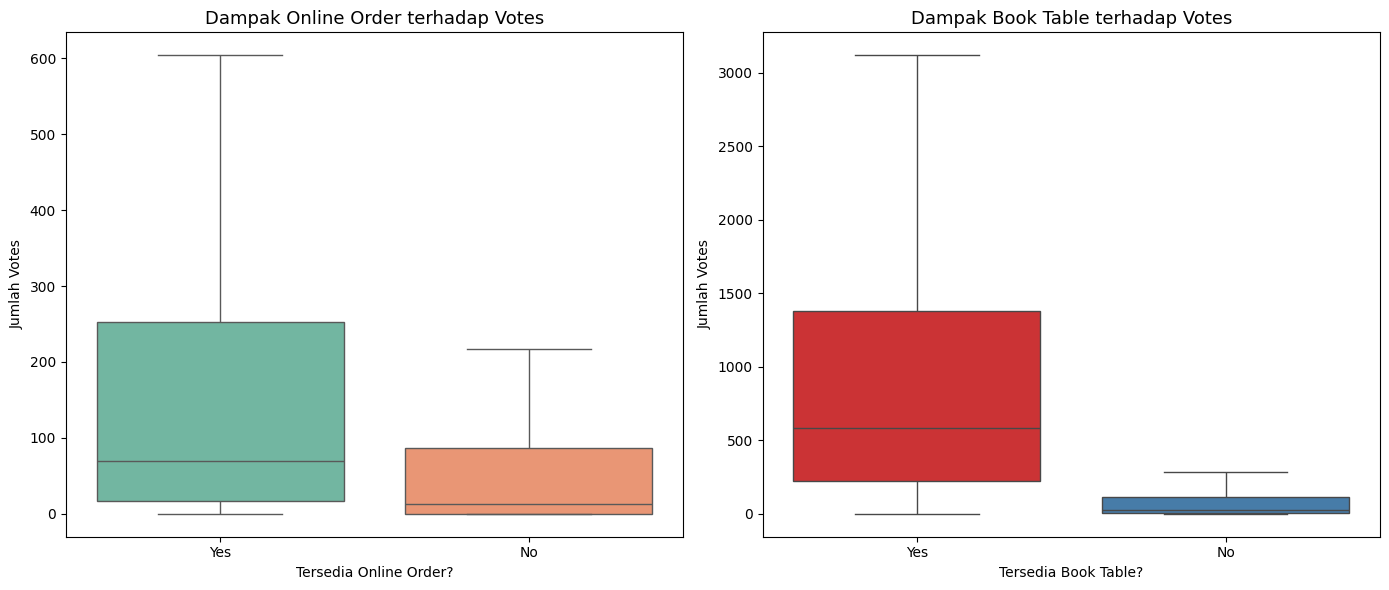

In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Pengaruh Online Order terhadap Votes
plt.subplot(1, 2, 1)
sns.boxplot(x='online_order', y='votes', data=df, showfliers=False, palette='Set2')
plt.title('Dampak Online Order terhadap Votes', fontsize=13)
plt.xlabel('Tersedia Online Order?')
plt.ylabel('Jumlah Votes')

# Subplot 2: Pengaruh Book Table terhadap Votes
plt.subplot(1, 2, 2)
sns.boxplot(x='book_table', y='votes', data=df, showfliers=False, palette='Set1')
plt.title('Dampak Book Table terhadap Votes', fontsize=13)
plt.xlabel('Tersedia Book Table?')
plt.ylabel('Jumlah Votes')

plt.tight_layout()
plt.show()
# showfliers=False digunakan agar grafik tetap rapi dan tidak terganggu oleh data yang saking populernya berada jauh di atas/outlier

**Hasil Analisis Fitur Digital:**

| Fitur | Tidak Ada | Ada | Selisih |
|---|---|---|---|
| Online Order → Votes | 324.7 | 322.9 | ~sama |
| Online Order → Rating | 3.65 | 3.72 | +0.07 |
| Book Table → Votes | 193.3 | **1.077.2** | **+457%** |
| Book Table → Rating | 3.62 | **4.13** | **+0.51** |

**Insight:**
- **Online Order** tidak menunjukkan perbedaan signifikan pada jumlah votes, namun sedikit meningkatkan rating — kemungkinan karena pelanggan delivery yang puas lebih terdorong memberi ulasan
- **Book Table** adalah fitur yang paling impactful — restoran dengan fitur reservasi memiliki rata-rata votes **5,5x lebih tinggi** dan rating **0.5 poin lebih baik**
- Book Table sangat terkait dengan segmen Casual Dining dan Fine Dining yang secara alamiah memiliki pelanggan lebih engaged dan pengalaman yang lebih terencana
- **Implikasi strategi:** Jika membuka restoran di segmen Casual/Fine Dining, aktifkan fitur Book Table sejak awal. Untuk Quick Bites, prioritaskan Online Order untuk menjangkau pasar delivery

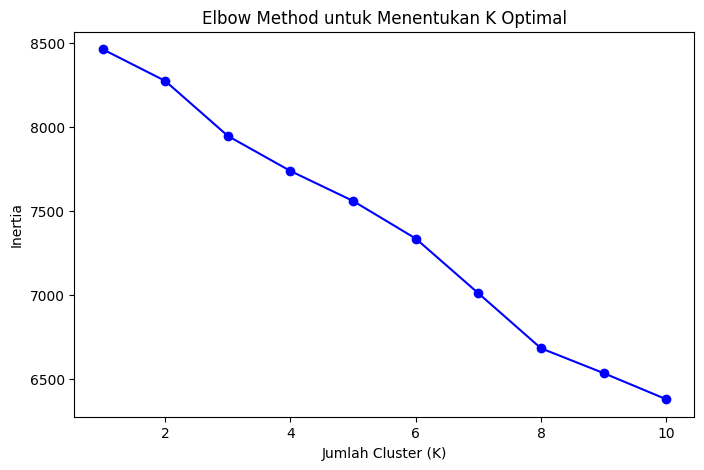

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#mengubah kategorikal menjadi numerik pakai one hot encoding pada kolom cuisine_main
cuisine_dummies = pd.get_dummies(df['cuisine_main'], prefix='cuisine')
# menggabungkan ketiga kolom ini dengan kolom hasil encode tadi didalam dataframe sementara
df_temp = pd.concat([df[['location', 'rate', 'cost']], cuisine_dummies], axis=1)

# mengelompokan data berdasarkan lokasi dan hitung nilai rata-rata di setiap lokasi
df_cluster = df_temp.groupby('location').mean()
df_cluster = df_cluster.fillna(0) # isi null dengan 0

# melakukan standarisasi aga semua fitur skala nya sama
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

inertia = []
K_range = range(1, 11)

# Melakukan perulangan untuk mencari jumlah klaster (K) terbaik menggunakan metode Elbow
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.show()


Terdapat titik "siku" (patahan di mana penurunan inertia mulai melambat secara signifikan) terlihat paling jelas pada angka K=4 atau K=5.

Karena bengaluru terlalu kompleks wilayahnya, maka diputuskan untuk menggunakan K=5, dengan 5 cluster maka pengelompokan wilayah akan jauh lebih mendetail dan mampu memisahkan area ekstrem dengan lebih baik

### 6.2 K-Means Clustering Wilayah Bengaluru

Setelah menentukan K optimal melalui Elbow Method, digunakan **K=5** untuk mengelompokkan wilayah berdasarkan profil: rata-rata rating, harga, sentimen pelanggan, votes, dan distribusi masakan.

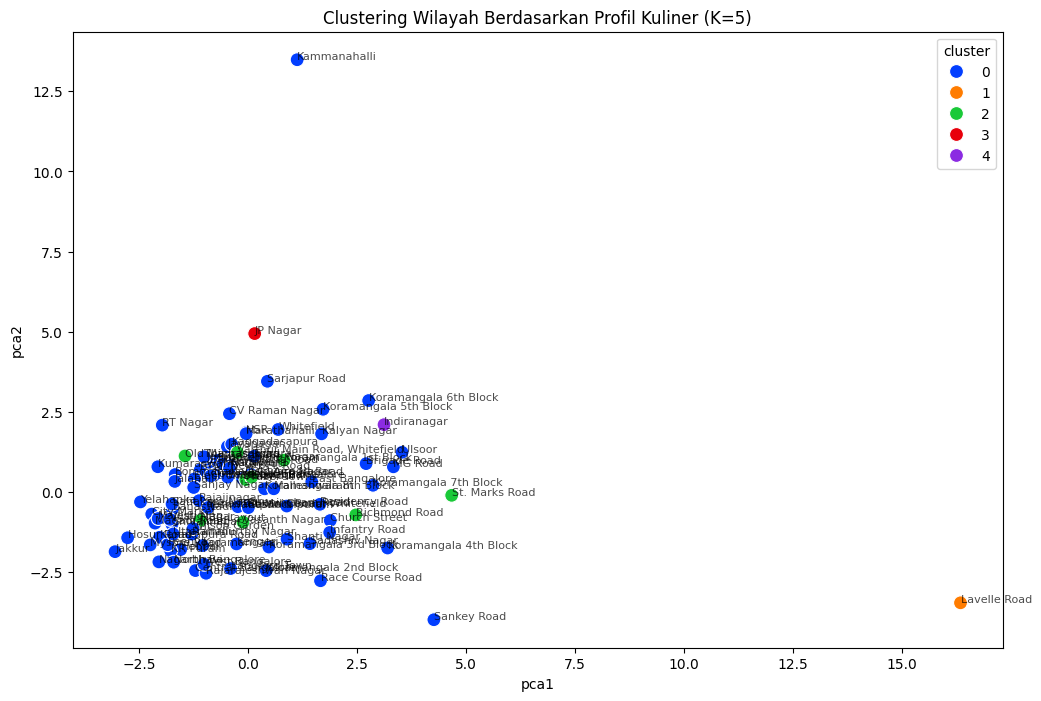

In [ ]:
# menjalankan KMeans dengan K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(df_scaled)

# Reduksi dimensi dengan PCA untuk visualisasi 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)
df_cluster['pca1'] = pca_result[:, 0]
df_cluster['pca2'] = pca_result[:, 1]

# Plot Scatter
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df_cluster, palette='bright', s=100)

# menambahkan label nama lokasi agar kita tahu wilayah mana masuk cluster mana
for i, txt in enumerate(df_cluster.index):
    plt.annotate(txt, (df_cluster.pca1.iat[i], df_cluster.pca2.iat[i]), fontsize=8, alpha=0.7)

plt.title('Clustering Wilayah Berdasarkan Profil Kuliner (K=5)')
plt.show()


**Interpretasi PCA Scatter Plot:**
- Titik yang **berdekatan** = wilayah dengan profil pasar yang mirip (bisa saling dijadikan referensi benchmark)
- Titik yang **berpencar jauh** = wilayah dengan karakter unik yang berbeda signifikan dari mayoritas
- Tumpukan besar di area tengah-kiri = mayoritas wilayah Bengaluru memiliki profil pasar yang serupa (kompetisi merata)
- Outlier seperti **Lavelle Road** menunjukkan pasar premium yang sangat berbeda dari wilayah lainnya

In [ ]:
# Mencari karakteristik tiap cluster
summary_cluster = df_cluster.groupby('cluster').mean()

# Menampilkan 3 masakan paling dominan di tiap cluster
def get_top_cuisines(row):
    # Ambil kolom yang diawali 'cuisine_'
    cuisines = row[[c for c in row.index if 'cuisine_' in c]]
    return ", ".join(cuisines.nlargest(3).index).replace('cuisine_', '')

summary_cluster['Top Cuisines'] = summary_cluster.apply(get_top_cuisines, axis=1)

# Tampilkan ringkasan (Harga, Rating, dan Masakan)
print(summary_cluster[['rate', 'cost', 'Top Cuisines']])


             rate         cost                         Top Cuisines
cluster                                                            
0        3.578259   538.679180  North Indian, South Indian, Chinese
1        4.132120  1304.274354    North Indian, Bakery, Continental
2        3.638090   511.838005  North Indian, South Indian, Biryani
3        3.674736   522.266546     North Indian, South Indian, Cafe
4        3.821512   644.574736      North Indian, Cafe, Continental


### Profil Strategis Tiap Cluster

**Cluster 0 — Premium Enclave** *(Lavelle Road)*
- Rating: **4.13** | Harga: **Rp 1.364** | Votes: **993**
- Wilayah eksklusif dengan standar tertinggi dan pelanggan paling demanding
- Masakan dominan: North Indian, Continental, Bakery
- **Rekomendasi:** Hanya masuk jika memiliki modal besar dan kualitas exceptional. Potensi revenue tertinggi tapi barrier to entry sangat tinggi

**Cluster 1 — Mass Market** *(43 wilayah: BTM, HSR, Whitefield, Marathahalli, dll)*
- Rating: **3.57** | Harga: **Rp 463** | Votes: **143**
- Mayoritas wilayah Bengaluru masuk cluster ini — pasar volume tinggi, price-sensitive
- Masakan dominan: North Indian, South Indian, Chinese
- **Rekomendasi:** Cocok untuk Quick Bites / Fast Food dengan harga terjangkau dan efisiensi operasional tinggi. Kompetisi paling ketat

**Cluster 2 — Underperforming Area** *(RT Nagar)*
- Rating: **3.46** | Harga: **Rp 443** | Votes: **107**
- Profil mirip Cluster 1 namun performa lebih rendah — pasar belum mature
- **Rekomendasi:** Risiko moderat, namun bisa jadi peluang first-mover bagi restoran yang mampu mengedukasi pasar lokal

**Cluster 3 — Premium Mid-Market** *(27 wilayah: Koramangala, Indiranagar, MG Road, Jayanagar, dll)*
- Rating: **3.80** | Harga: **Rp 744** | Votes: **391**
- Wilayah mapan dengan pelanggan yang selektif namun tidak sekelas premium enclave
- Masakan dominan: North Indian, Cafe, South Indian
- **Rekomendasi:** Sweet spot terbaik untuk restoran baru — standar kualitas jelas, daya beli memadai, dan ada ruang untuk konsep premium yang terjangkau. Prioritaskan konsep Cafe atau Casual Dining dengan branding kuat

---

### 🎯 Kesimpulan Strategis untuk Calon Pemilik Restoran

| Pertanyaan Bisnis | Temuan | Rekomendasi |
|---|---|---|
| Di mana buka restoran? | Cluster 3 (Koramangala, Indiranagar) adalah sweet spot terbaik | Hindari Cluster 1 jika tidak siap perang harga |
| Masakan apa yang dipilih? | North Indian paling universal, Ice Cream/Dessert underserved | Pertimbangkan dessert di area premium |
| Waralaba atau independen? | Waralaba unggul jauh dalam votes & rating | Independen harus punya diferensiasi kuat |
| Fitur digital apa yang wajib? | Book Table dampaknya 5.5x lebih besar dari Online Order | Aktifkan Book Table sejak hari pertama (jika Casual Dining) |
| Apakah harga menentukan sukses? | Korelasi harga-sentimen hanya 0.099 | Fokus pada kualitas pengalaman, bukan markup harga |